# Exploring the credit-card fraud dataset

284,807 card transactions made by European cardholders over two days in September 2013 ([ULB Machine Learning Group](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)). `V1`–`V28` are PCA components the bank used to anonymise the original features; `Time` and `Amount` are raw.

The questions here: how rare is fraud, what differs between fraud and normal transactions, and how should the data be split?

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, "../src")
from fraud.data import load_transactions  # noqa: E402
from fraud.features import add_features  # noqa: E402

plt.rcParams.update({"figure.figsize": (8, 3.5), "axes.spines.top": False, "axes.spines.right": False})
df = add_features(load_transactions("../data/creditcard.csv"))
df.shape

(284807, 34)

## 1. Fraud is extremely rare

In [2]:
counts = df["Class"].value_counts().rename({0: "Legit", 1: "Fraud"})
print(counts.to_string())
print(f"\nFraud rate: {df['Class'].mean():.3%}")
print(f"Accuracy of always predicting 'legit': {1 - df['Class'].mean():.3%}")

Class
Legit    284315
Fraud       492

Fraud rate: 0.173%
Accuracy of always predicting 'legit': 99.827%


A model that never flags anything is **99.83% accurate**, so accuracy is useless here. The project uses **precision-recall AUC** and the **dollar cost** of each decision threshold instead.

## 2. Amounts

          count    mean     std  min   25%    50%     75%       max
Class                                                              
Legit  284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
Fraud     492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


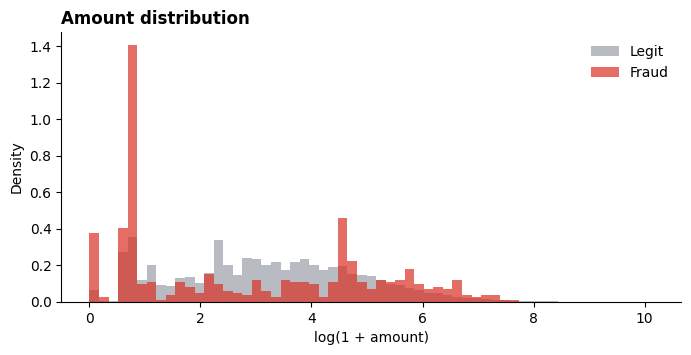

In [3]:
print(df.groupby("Class")["Amount"].describe().rename(index={0: "Legit", 1: "Fraud"}).round(2).to_string())

fig, ax = plt.subplots()
bins = np.linspace(0, np.log1p(df["Amount"].max()), 60)
ax.hist(df.loc[df.Class == 0, "log_amount"], bins=bins, density=True, alpha=0.6, label="Legit", color="#8a8f98")
ax.hist(df.loc[df.Class == 1, "log_amount"], bins=bins, density=True, alpha=0.7, label="Fraud", color="#d93025")
ax.set_xlabel("log(1 + amount)")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.set_title("Amount distribution", loc="left", fontweight="bold");

Amounts are heavily skewed, so the model uses `log(1 + amount)`. Half of all frauds are under $10 (card testing is a common explanation), but some run into the thousands. Amount alone can't separate the classes, but it matters for **cost**: missing a $1,000 fraud is far worse than missing a $1 one.

## 3. Time of day

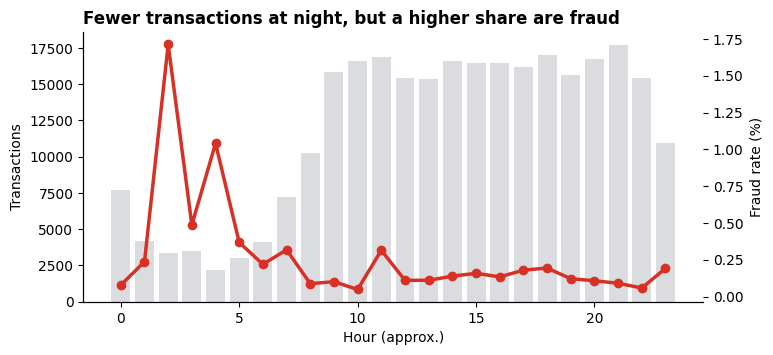

In [4]:
hour = ((df["Time"] % 86_400) // 3_600).astype(int)
by_hour = df.groupby(hour)["Class"].agg(["mean", "size"])

fig, ax1 = plt.subplots()
ax1.bar(by_hour.index, by_hour["size"], color="#dadce0", label="Transactions")
ax1.set_xlabel("Hour (approx.)")
ax1.set_ylabel("Transactions")
ax2 = ax1.twinx()
ax2.plot(by_hour.index, by_hour["mean"] * 100, color="#d93025", lw=2.5, marker="o", label="Fraud rate")
ax2.set_ylabel("Fraud rate (%)")
ax1.set_title("Fewer transactions at night, but a higher share are fraud", loc="left", fontweight="bold");

Overnight hours have far fewer transactions but a much higher fraud *rate*. The model encodes the hour as `sin`/`cos` so 23:00 and 00:00 end up close together.

## 4. Which components separate fraud?

V17   -0.326
V14   -0.303
V12   -0.261
V10   -0.217
V16   -0.197
V3    -0.193
V7    -0.187
V11    0.155


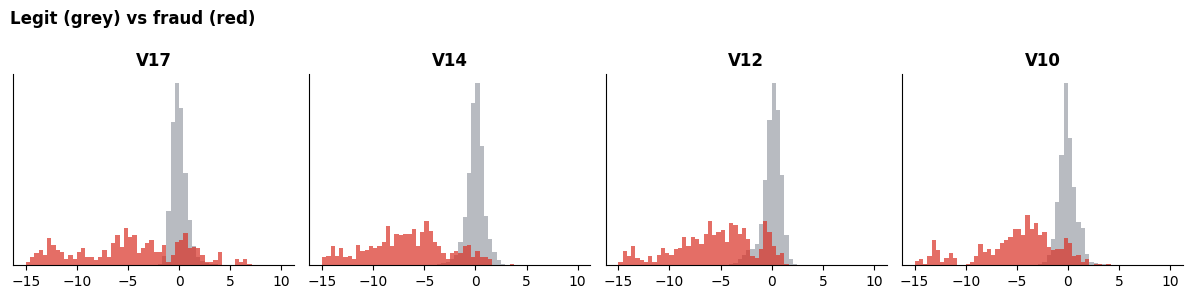

In [5]:
corr = df[[f"V{i}" for i in range(1, 29)] + ["Class"]].corr()["Class"].drop("Class")
top = corr.abs().sort_values(ascending=False).head(8).index
print(corr[top].round(3).to_string())

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, col in zip(axes, top[:4], strict=True):
    ax.hist(df.loc[df.Class == 0, col], bins=60, density=True, alpha=0.6, color="#8a8f98", range=(-15, 10))
    ax.hist(df.loc[df.Class == 1, col], bins=60, density=True, alpha=0.7, color="#d93025", range=(-15, 10))
    ax.set_title(col, fontweight="bold")
    ax.set_yticks([])
fig.suptitle("Legit (grey) vs fraud (red)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout();

A handful of components (V17, V14, V12, V10…) shift strongly for fraud. Since they're anonymised we can't say what they *mean*, but tree models can use them well.

## 5. How to split the data

In [6]:
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Time span: {df['Time'].max() / 3600:.1f} hours")

Exact duplicate rows: 1,081
Time span: 48.0 hours


- **Split by time, not at random.** In production a model only ever scores *future* transactions. Training on earlier data and testing on later data gives a more honest estimate than a random split. The pipeline uses 64% fit / 16% validation / 20% test, all in time order.
- **Duplicates are kept.** Identical rows can be genuine repeat transactions, and dropping them would change the class balance the model sees in production.
- **Class imbalance** is handled with class weights, not oversampling (SMOTE), which keeps the pipeline simple and avoids leaking synthetic points into validation.

Model results are in [`reports/metrics.json`](../reports/metrics.json) and in the dashboard.